# Обедающие философы: базовые эксперименты

Этот literate-скрипт воспроизводит основную часть лабораторной работы 5.
Он строит классическую сеть Петри и её модификацию с арбитром,
выполняет стохастическое и детерминированное моделирование
и сохраняет траектории, графики и GIF-анимацию.

## Подключение библиотек

In [1]:
using DrWatson
@quickactivate "lab_05_models"

ENV["GKSwstype"] = "100"

include(joinpath(@__DIR__, "..", "src", "DiningPhilosophers.jl"))
using .DiningPhilosophers
using CSV
using DataFrames
using Plots
using Random

mkpath(datadir())
mkpath(plotsdir())

"/home/asvedjmina/university/imit-model/2026-1--study--simulation-modeling/labs/lab05/lab_05_models/plots"

## Базовые параметры

Используется стандартная постановка из пяти философов
и горизонт моделирования `50` единиц времени.

In [2]:
N = 5
tmax = 50.0
classic_seed = 2026
arbiter_seed = 2027

2027

## Сети Петри

Сначала формируются две сети:
классическая и модифицированная с арбитром.

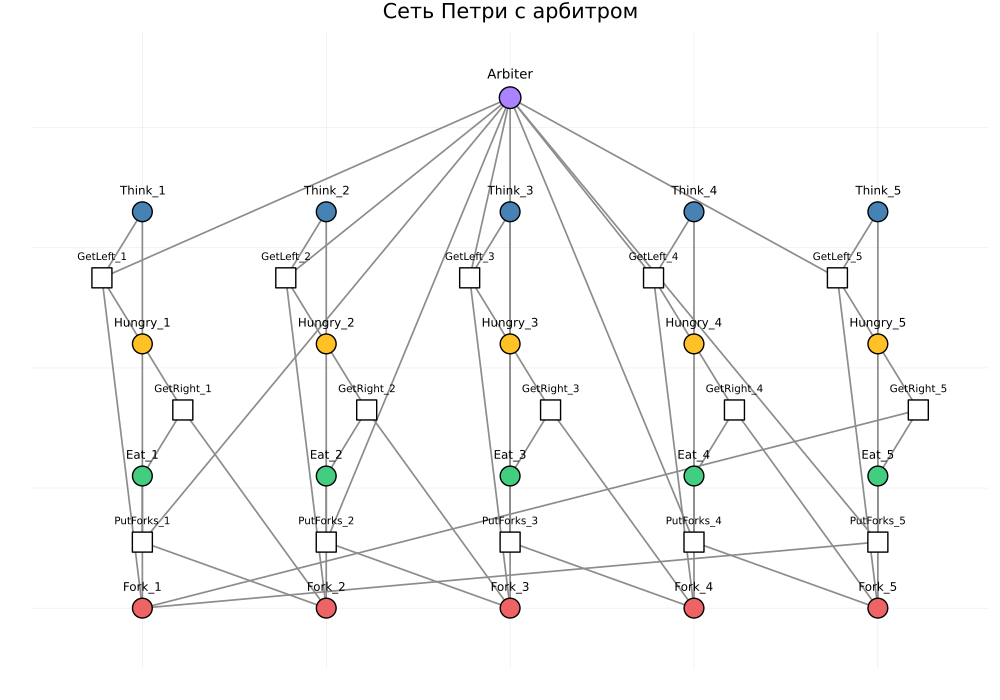

In [3]:
net_classic, u0_classic, _ = build_classical_network(N)
net_arbiter, u0_arbiter, _ = build_arbiter_network(N)

classic_network_plot = plot_network(net_classic)
arbiter_network_plot = plot_network(net_arbiter)

classic_network_plot
arbiter_network_plot

## Стохастическое моделирование

Для каждой сети выполняется симуляция по алгоритму Гиллеспи.

In [4]:
df_classic = simulate_stochastic(
    net_classic,
    u0_classic,
    tmax;
    rng = MersenneTwister(classic_seed),
)
df_arbiter = simulate_stochastic(
    net_arbiter,
    u0_arbiter,
    tmax;
    rng = MersenneTwister(arbiter_seed),
)

CSV.write(datadir("dining_classic.csv"), df_classic)
CSV.write(datadir("dining_arbiter.csv"), df_arbiter)

deadlock_classic = detect_deadlock(df_classic, net_classic)
deadlock_arbiter = detect_deadlock(df_arbiter, net_arbiter)

deadlock_summary = DataFrame(
    model = ["classic", "arbiter"],
    deadlock = [deadlock_classic, deadlock_arbiter],
    deadlock_time = [
        deadlock_time(df_classic, net_classic),
        deadlock_time(df_arbiter, net_arbiter),
    ],
    final_total_eaters = [
        total_eaters(df_classic, N)[end],
        total_eaters(df_arbiter, N)[end],
    ],
)
deadlock_summary

Row,model,deadlock,deadlock_time,final_total_eaters
,String,Bool,Float64?,Float64
1,classic,true,0.629704,0.0
2,arbiter,false,missing,1.0


## Графики маркировки

Динамика по позициям позволяет визуально увидеть,
что в классической сети система приходит к тупику,
а с арбитром остаётся активной.

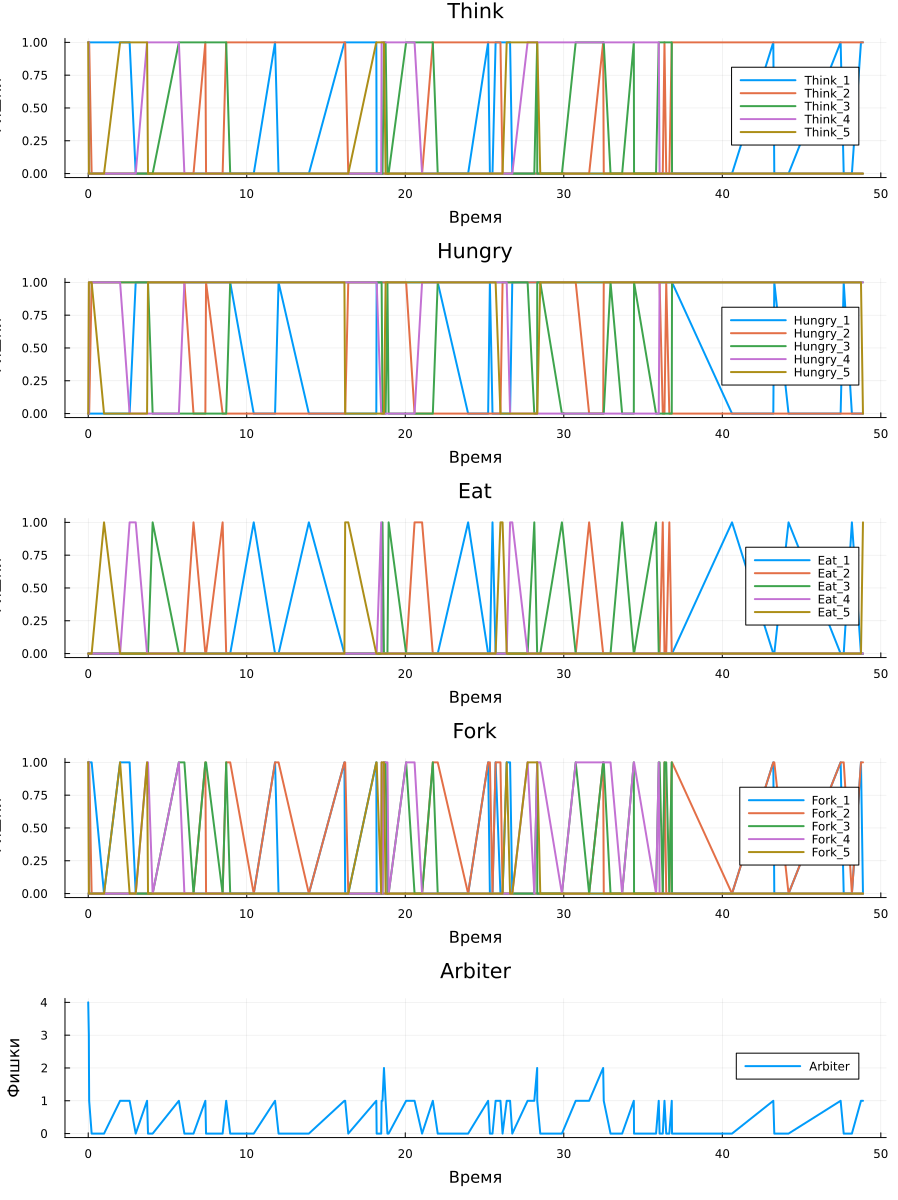

In [5]:
classic_marking_plot = plot_marking_evolution(df_classic, net_classic)
arbiter_marking_plot = plot_marking_evolution(df_arbiter, net_arbiter)

classic_marking_plot
arbiter_marking_plot

## Детерминированная аппроксимация

Для сравнения строится
простая mean-field аппроксимация по тем же сетям.

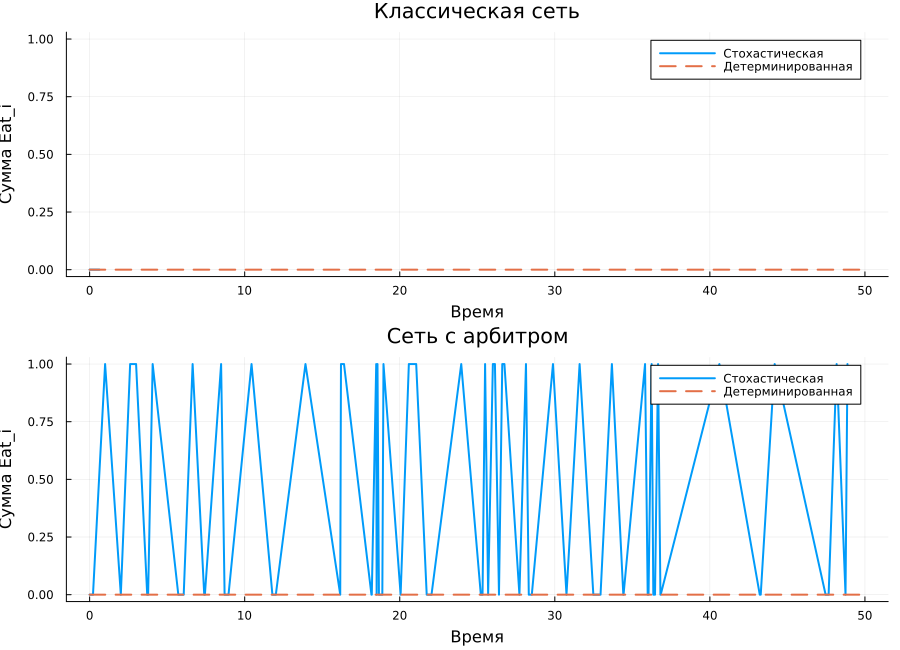

In [6]:
df_classic_det = simulate_deterministic(net_classic, u0_classic, tmax)
df_arbiter_det = simulate_deterministic(net_arbiter, u0_arbiter, tmax)

deterministic_plot = plot_total_eaters_comparison(
    df_classic,
    df_classic_det,
    df_arbiter,
    df_arbiter_det,
    N,
)
deterministic_plot

## Сравнение по состояниям `Eat_i`

Итоговый график сопоставляет количество философов
в состоянии приёма пищи для двух вариантов сети.

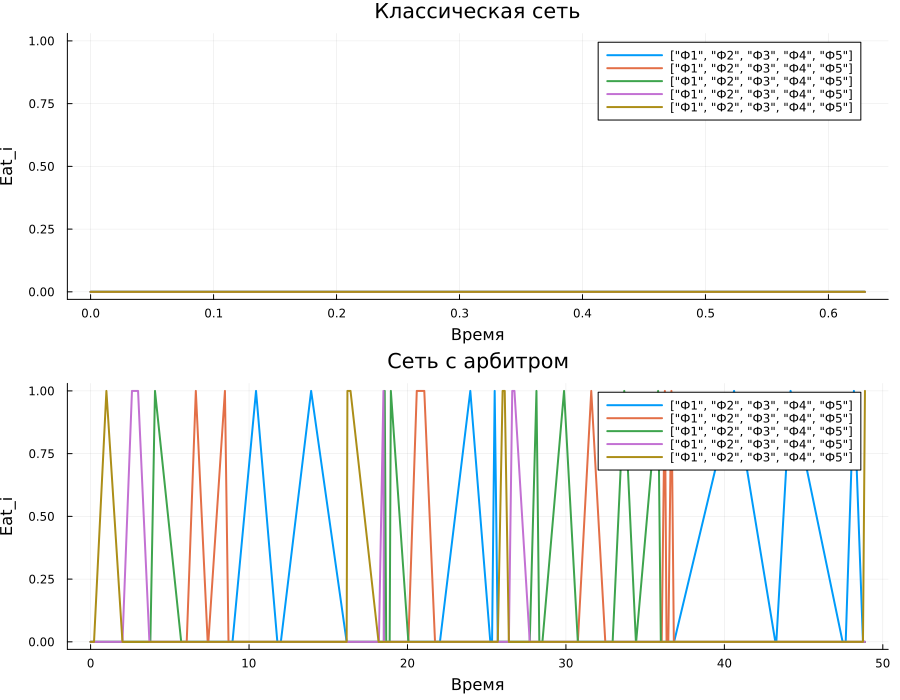

In [7]:
final_report_plot = plot_eating_comparison(df_classic, df_arbiter, N)
final_report_plot

## Анимация

Для наглядности дополнительно строится GIF-анимация
для классической сети при `N = 3`.

In [8]:
net_anim, u0_anim, _ = build_classical_network(3)
df_anim = simulate_stochastic(net_anim, u0_anim, 30.0; rng = MersenneTwister(123))

Row,time,Think_1,Think_2,Think_3,Hungry_1,Hungry_2,Hungry_3,Eat_1,Eat_2,Eat_3,Fork_1,Fork_2,Fork_3
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,0.327354,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.739835,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.945876,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,1.63224,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
6,1.66355,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7,1.84545,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Краткие выводы

1. В классической сети при выбранном `seed` возникает deadlock.
2. В модификации с арбитром deadlock не возникает.
3. Детерминированная аппроксимация подтверждает,
   что арбитр поддерживает ненулевой поток
   переходов в состояниях `Eat_i`.